In [1]:
import pandas as pd

In [2]:
models = ['rf', 'gcn']

In [3]:
# solubility
for model in models:
    print(model)
    df = pd.read_pickle(f'../3_solubility/{model}_regression_solubility/df_explanation.pkl')
    vals = df.fragExplainer_expected_value.unique()
    print(f'   mean: {vals.mean():.3f}, std: {vals.std():.3f}')

rf
   mean: -1.211, std: 0.167
gcn
   mean: -0.939, std: 0.482


In [4]:
import numpy as np
def logit_to_prob(logit):
    
    return 1 / (1 + np.exp(-logit))

In [5]:
# mutagenicity
for model in models:
    print(model)
    df = pd.read_pickle(f'../4_mutagenicity/{model}_classification_hansen/df_explanation.pkl')
    vals = df.fragExplainer_expected_value.unique()
    print(f'   mean: {vals.mean():.3f}, std: {vals.std():.3f}')
    print(f'   mean (prob): {logit_to_prob(vals.mean()):.3f}')

rf
   mean: 0.081, std: 0.024
   mean (prob): 0.520
gcn
   mean: 0.350, std: 0.274
   mean (prob): 0.587


In [8]:
# now potency

for model in models:
    print(model)
    df = pd.read_pickle(f'../5_potency/{model}_regression_potency/df_explanation.pkl').query('dataset == "SARS"')
    vals = df.fragExplainer_expected_value.unique()
    print(f'   mean: {vals.mean():.3f}, std: {vals.std():.3f}')

rf
   mean: 5.679, std: 0.000
gcn
   mean: 5.024, std: 0.000


In [17]:
# Some more analysis

In [26]:
model = 'rf'
split = 0

df = pd.read_pickle(f'../3_solubility/{model}_regression_solubility/df_explanation.pkl')
df_split = df[df.split == split].copy()

In [27]:
import pickle

with open(f"../3_solubility/{model}_regression_solubility/models/model_{model}r_esol_delaney_split_{split}.pkl", "rb") as f:
    model = pickle.load(f)


In [28]:
import sys
sys.path.append('../')
import FragShapley
from rdkit.Chem import rdFingerprintGenerator

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)


frag_explainer = FragShapley.FragmentExplainer(model=model,
                                               fingerprint_generator=mfpgen,
                                               fragmentation_method='BRICS',
                                               expected_value=0.0)

smiles_test = df_split.smiles.to_list()
results_dicts, frag_to_atom_ids, atom_id_to_bits = frag_explainer.explain(smiles_test, return_atom_id_to_bits=True)

[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-1.06374]
[array([0, 1, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-1.529625]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-1.06374]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-7.075935]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-1.06374]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-3.148355]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-1.06374]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-1.288865]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-1.06374]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-3.4560625]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-1.06374]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8)] [-6.612695]
[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,), dtype=uint8), array([0

In [33]:
df_split['fragExplainer_results_alt'] = results_dicts
df_split['fragExplainer_expected_value_alt'] = frag_explainer.expected_value

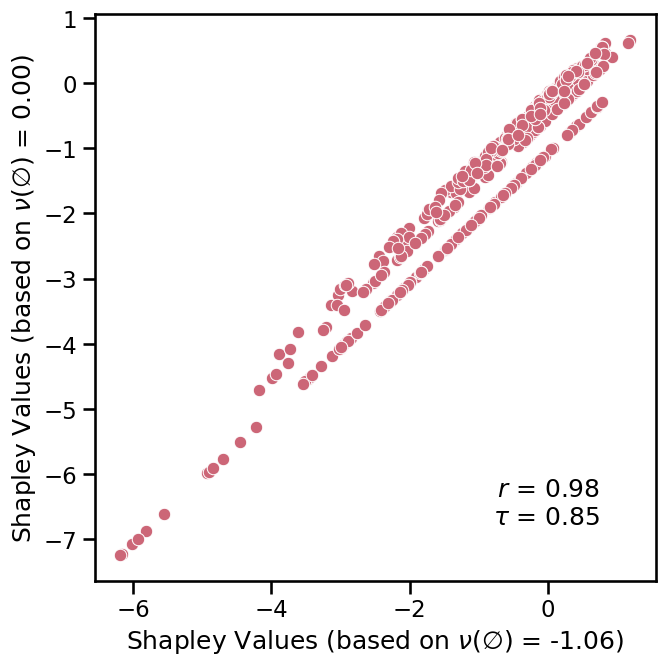

In [95]:
# scatter plot them now
df_split['fragExplainer_shapley_values'] = df_split['fragExplainer_result'].apply(lambda x: list(x.values()))
df_split['fragExplainer_shapley_values_alt'] = df_split['fragExplainer_results_alt'].apply(lambda x: list(x.values()))

original_values = [val for vals in df_split['fragExplainer_shapley_values'] for val in vals]
modified_values = [val for vals in df_split['fragExplainer_shapley_values_alt'] for val in vals]

import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, kendalltau

plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)
fig_folder = os.path.abspath("figures/")


fig, axs = plt.subplots(1, 1, figsize=(7, 7))

sns.scatterplot(x=original_values, 
                y=modified_values,
                ax=axs)

# add statistics
pearson_stat = pearsonr(original_values, modified_values)
kendall_stat = kendalltau(original_values, modified_values)

axs.text(x=0.90,
         y=0.15,
         s='$r$'+f' = {pearson_stat.statistic:.2f}',
         transform=axs.transAxes,
         ha='right')
axs.text(x=0.90,
         y=0.10,
         s='$\\tau$'+f' = {kendall_stat.statistic:.2f}',
         transform=axs.transAxes,
         ha='right')

axs.set_xlabel(f'Shapley Values (based on $\\nu(\\emptyset)$ = {df_split.fragExplainer_expected_value.unique()[0]:.2f})')
axs.set_ylabel(f'Shapley Values (based on $\\nu(\\emptyset)$ = {0.0:.2f})')

fig.tight_layout()

fig.savefig(os.path.join(fig_folder, f'final_figures/S_shapley_values_comparison_{model}_split{split}.pdf'))

In [83]:
# now get the ranking of the fragments

df_split['fragments'] = df_split.smiles.apply(lambda x: FragShapley.utils.get_BRICS_fragments_as_SMILES(x, remove_dummies=False))

min_n = 5

In [79]:
# first with original ones
df_fragments = df_split[['fragments', 'fragExplainer_shapley_values']].copy()
df_fragments = df_fragments[['fragments', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)

df_fragments = df_fragments.groupby('fragments').agg([len, 'mean', 'std', list]) # will throw warning veacuse of error when calculating std for a single measurement
df_fragments = df_fragments.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_fragments.columns = [col[0] if col[1]=='' else col[1] for col in df_fragments.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std

In [84]:
df_fragments.query('len >= @min_n').sort_values('mean')

,fragments,len,mean,std,list
125,*c1ccccc1,17,-1.255114,0.540985,"[-1.8889112499999952, -1.730881250000011, -0.8..."
60,*CCCC,6,-1.174054,0.316144,"[-0.7855587499999982, -1.1478190729166688, -1...."
16,*C(C)C,9,-0.401696,0.105572,"[-0.2885898750000007, -0.2885898750000007, -0...."
65,*N(*)*,5,-0.307221,0.336701,"[-0.18487508333333344, -0.0899022083333318, -0..."
56,*CC=C,6,-0.25326,0.071610,"[-0.2055991666666659, -0.2055991666666659, -0...."
48,*CC,29,-0.080285,0.108667,"[-0.14974333333333312, -0.14974333333333312, -..."
69,*N(C)C,6,-0.007244,0.065058,"[0.00044333333333344827, -0.074680833333333, 0..."
80,*O*,24,0.004284,0.229587,"[0.002163749999999562, -0.09455360119047668, -..."
70,*N*,23,0.039625,0.030950,"[0.13689458333333393, 0.04112775000000233, 0.0..."
63,*CO,5,0.356137,0.218213,"[0.5816790000000003, 0.3995356666666663, 0.399..."


In [85]:
# now for mod 
# first with original ones
df_fragments_alt = df_split[['fragments', 'fragExplainer_shapley_values_alt']].copy()
df_fragments_alt = df_fragments_alt[['fragments', 'fragExplainer_shapley_values_alt']].explode(['fragments', 'fragExplainer_shapley_values_alt'], ignore_index=True)

df_fragments_alt = df_fragments_alt.groupby('fragments').agg([len, 'mean', 'std', list]) # will throw warning veacuse of error when calculating std for a single measurement
df_fragments_alt = df_fragments_alt.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_fragments_alt.columns = [col[0] if col[1]=='' else col[1] for col in df_fragments_alt.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std

In [86]:
df_fragments_alt.query('len >= @min_n').sort_values('mean')

,fragments,len,mean,std,list
125,*c1ccccc1,17,-1.629062,0.622335,"[-2.4207812499999948, -2.2627512500000106, -1...."
60,*CCCC,6,-1.466582,0.425342,"[-0.9983067499999979, -1.3251090729166688, -1...."
16,*C(C)C,9,-0.672697,0.162491,"[-0.5013378750000005, -0.5013378750000005, -0...."
56,*CC=C,6,-0.637389,0.135167,"[-0.5601791666666657, -0.5601791666666657, -0...."
65,*N(*)*,5,-0.498694,0.347086,"[-0.36216508333333336, -0.3026502083333317, -1..."
48,*CC,29,-0.370674,0.183252,"[-0.5043233333333329, -0.5043233333333329, -0...."
69,*N(C)C,6,-0.284999,0.105435,"[-0.3541366666666663, -0.4292608333333328, -0...."
80,*O*,24,-0.230151,0.208684,"[-0.2637712500000003, -0.24651645833333366, -0..."
70,*N*,23,-0.174775,0.063543,"[-0.21768541666666583, -0.17162024999999756, -..."
81,*OC,17,-0.000179,0.136071,"[-0.1487662499999999, -0.3177237500000011, -0...."


In [87]:
df_joined = df_fragments.merge(df_fragments_alt, on='fragments', suffixes=('_orig', '_mod'))

In [90]:
df_stat = df_joined.query('len_orig >= @min_n and len_mod >= @min_n')

In [103]:
df_stat

,fragments,len_orig,mean_orig,std_orig,list_orig,len_mod,mean_mod,std_mod,list_mod
4,*C(*)=O,17,0.421101,0.201640,"[0.5503297916666664, 0.15656156547619088, 0.65...",17,0.204629,0.166936,"[0.2843947916666665, 0.004598708333333763, 0.2..."
15,*C(C)=O,8,0.527315,0.278102,"[0.28747799999999873, 0.8248170833333328, 0.56...",8,0.179383,0.254425,"[0.07472999999999883, 0.47023708333333303, 0.2..."
16,*C(C)C,9,-0.401696,0.105572,"[-0.2885898750000007, -0.2885898750000007, -0....",9,-0.672697,0.162491,"[-0.5013378750000005, -0.5013378750000005, -0...."
48,*CC,29,-0.080285,0.108667,"[-0.14974333333333312, -0.14974333333333312, -...",29,-0.370674,0.183252,"[-0.5043233333333329, -0.5043233333333329, -0...."
56,*CC=C,6,-0.25326,0.071610,"[-0.2055991666666659, -0.2055991666666659, -0....",6,-0.637389,0.135167,"[-0.5601791666666657, -0.5601791666666657, -0...."
60,*CCCC,6,-1.174054,0.316144,"[-0.7855587499999982, -1.1478190729166688, -1....",6,-1.466582,0.425342,"[-0.9983067499999979, -1.3251090729166688, -1...."
63,*CO,5,0.356137,0.218213,"[0.5816790000000003, 0.3995356666666663, 0.399...",5,0.115023,0.188801,"[0.22709900000000055, 0.1867876666666664, 0.18..."
65,*N(*)*,5,-0.307221,0.336701,"[-0.18487508333333344, -0.0899022083333318, -0...",5,-0.498694,0.347086,"[-0.36216508333333336, -0.3026502083333317, -1..."
69,*N(C)C,6,-0.007244,0.065058,"[0.00044333333333344827, -0.074680833333333, 0...",6,-0.284999,0.105435,"[-0.3541366666666663, -0.4292608333333328, -0...."
70,*N*,23,0.039625,0.030950,"[0.13689458333333393, 0.04112775000000233, 0.0...",23,-0.174775,0.063543,"[-0.21768541666666583, -0.17162024999999756, -..."


In [98]:
original_values = df_stat['mean_orig'].to_list()
modified_values = df_stat['mean_mod'].to_list()
fragments = df_stat['fragments'].to_list()

In [105]:
kendalltau_stat = kendalltau(df_stat['mean_orig'], df_stat['mean_mod'])
pearson_stat = pearsonr(df_stat['mean_orig'].to_list(), df_stat['mean_mod'].to_list())

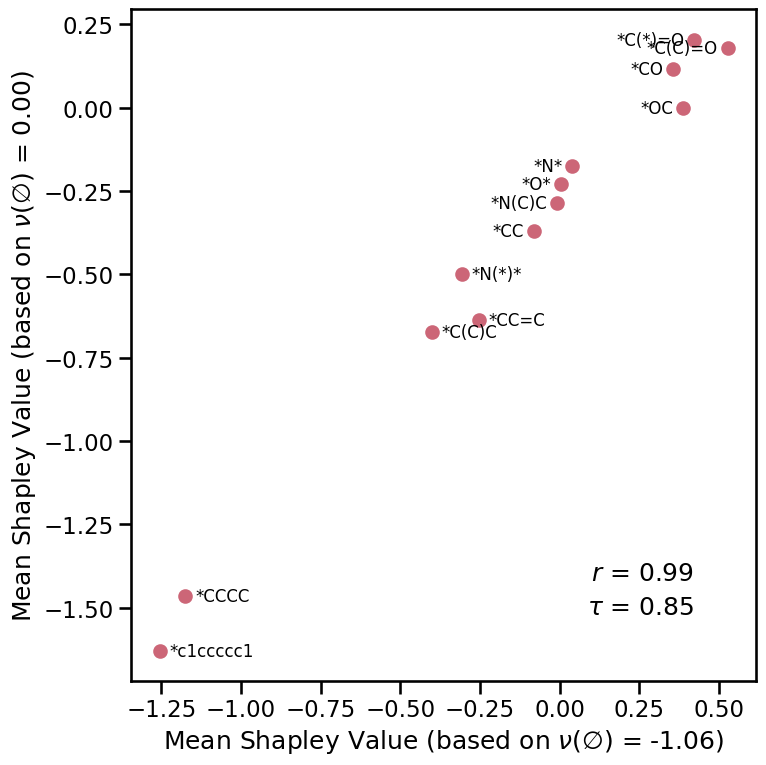

In [121]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(original_values  , modified_values)

for xi, yi, label in zip(original_values, modified_values, fragments):
    ax.annotate(
        label,
        (xi, yi),
        xytext=(7, 0) if xi < -0.25 else (-7, 0),
        textcoords="offset points",
        fontsize=12,
        ha='left' if xi < -0.25 else 'right',
        va='center'
    )

ax.set_xlabel(f'Mean Shapley Value (based on $\\nu(\\emptyset)$ = {df_split.fragExplainer_expected_value.unique()[0]:.2f})')
ax.set_ylabel(f'Mean Shapley Value (based on $\\nu(\\emptyset)$ = {0.0:.2f})')

ax.text(x=0.90,
         y=0.15,
         s='$r$'+f' = {pearson_stat.statistic:.2f}',
         transform=ax.transAxes,
         ha='right')
ax.text(x=0.90,
         y=0.10,
         s='$\\tau$'+f' = {kendall_stat.statistic:.2f}',
         transform=ax.transAxes,
         ha='right')
fig.tight_layout()
fig.savefig(os.path.join(fig_folder, f'final_figures/S_shapley_values_comparison_fragments_{model}_split{split}.pdf'))

1. Changes to the manuscript
Methods section

Add a short paragraph after the discussion of ν(∅):

The value of the empty coalition defines the reference point of the attribution decomposition. Because the empty input does not correspond to a physically meaningful molecule, the resulting Shapley values should be interpreted relative to the chosen baseline. To assess the sensitivity of the proposed framework to this choice, a baseline sensitivity analysis was performed (Supporting Information). While changes in the empty-coalition value alter the absolute attribution magnitudes, the relative fragment rankings and dataset-level attribution trends remained highly consistent.

Limitations section

Add something like:

The choice of empty-coalition baseline represents an additional modeling decision. Because the corresponding input lies outside the training distribution, alternative baseline choices may shift the attribution decomposition. However, sensitivity analysis demonstrated that the dominant fragment-level trends and rankings are largely preserved across different baseline choices (Supporting Information), suggesting that the main chemical conclusions are robust.

Results (optional, one sentence)

You could also mention it briefly:

A sensitivity analysis using alternative empty-coalition baselines yielded highly consistent fragment rankings and attribution trends (Figure Sx), indicating that the reported conclusions are not strongly dependent on the chosen baseline.

I would only add one sentence in the main text and keep the details in the SI.

2. New Supporting Information
Figure Sx

Scatter plot:

x-axis

Fragment-level Shapley values (default baseline)

y-axis

Fragment-level Shapley values (alternative baseline)

Include:

Pearson r=0.98
Kendall τ=0.85

Caption:

Comparison of fragment-level Shapley values obtained using the default empty-coalition baseline and an alternative baseline value of 0. Despite changes in the attribution offset, fragment-level attributions remain highly correlated (Pearson r=0.98, Kendall τ=0.85).

Table Sx

Empty coalition values:

Dataset	Model	ν(∅)
Solubility	RF	-1.211 ± 0.167
Solubility	GCN	-0.939 ± 0.482
Mutagenicity	RF	0.081 ± 0.024
Mutagenicity	GCN	0.350 ± 0.274
Potency	RF	5.305 ± 0.373
Potency	GCN	4.868 ± 0.156

For mutagenicity you can optionally additionally report the probabilities.

Figure or Table Sy

This is actually the strongest result.

Report:

Kendall τ=0.92

for the ranking of average fragment contributions.

For example:

Comparison	Kendall τ
Mean fragment ranking (default vs alternative baseline)	0.92

or a scatter plot of mean fragment contributions.

This directly addresses the reviewer's concern regarding chemical conclusions.

3. Response to reviewer

I would answer roughly as follows:

We thank the reviewer for this important observation. We agree that the empty-coalition input does not correspond to a physically meaningful molecule and lies outside the training distribution. Because fragment-level Shapley values are defined relative to this reference point, the choice of baseline influences the absolute attribution decomposition.

To address this concern, we now report the numerical values of the empty-coalition predictions for all models in the Supporting Information (Table Sx). In addition, we performed a sensitivity analysis in which fragment-level Shapley values were recomputed using an alternative baseline value. The resulting fragment-level attributions remained highly consistent with those obtained using the default baseline (Pearson r = 0.98, Kendall τ = 0.85; Figure Sx). Furthermore, aggregation of Shapley values across fragment types yielded highly similar fragment rankings (Kendall τ = 0.92), indicating that the dominant chemical trends and conclusions are largely invariant to the baseline choice.

We have expanded the manuscript to discuss the role of the empty-coalition baseline and its influence on the attribution decomposition.

I would perhaps acknowledge the scope of the analysis honestly:

As a representative test case, we performed the sensitivity analysis on the RF model for the aqueous solubility dataset.

That makes it clear you are not claiming universal validation.

In fact, there is a practical argument why a single representative analysis is sufficient:

The effect of changing ν(∅) is largely mathematical and model-independent. Once you demonstrate empirically that a substantial baseline shift does not meaningfully alter fragment rankings in one representative setting, the reviewer's conceptual concern is largely addressed.

So if I were revising the paper, I would stop here and spend my remaining effort on the comments that can actually move the paper forward scientifically:

analogue series / solubility validation,
toxicophore subset analysis,
dataset statistics and fragment-count distributions,
clarifying ECFP subset construction,
clarifying graph subset construction,
better discussion of MolSHAP and related methods.

Those are likely to have a much larger impact on acceptance than running baseline sensitivity analyses for every model and dataset combination.